# RSO-113: Compare thermal behavior across different louver configurations

Check whether different louver configurations lead to noticeable differences in how quickly or how strongly the dome and telescope temperatures respond to outside conditions.



Expected results:

**Plots**: temperature vs time with configuration highlighted

**Comparison tables**: how much temperatures change for each configuration

**Variation view**: results grouped by similar wind conditions (to avoid mixing very different nights)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
import matplotlib.dates as mdates
import matplotlib.cm as cm
import seaborn as sns

from lsst.summit.utils.efdUtils import getEfdData, makeEfdClient
from lsst.summit.utils.tmaUtils import TMAEventMaker, TMAState

In [2]:
t_start_period = Time("2026-01-31T00:00:00Z", scale="utc")
t_end_period = Time("2026-02-15T00:00:00Z", scale="utc")

efd_client = makeEfdClient()

# Queries

In [3]:
def query_setlouvers(start, end):
    df_louvers = getEfdData(
        client=efd_client,
        topic="lsst.sal.MTDome.command_setLouvers",
        columns=["*"],
        begin=start,
        end=end,
    )

    return df_louvers

In [4]:
def query_essTemperature(start, end):
    df_esstemperature = getEfdData(
        client=efd_client,
        topic="lsst.sal.ESS.temperature",
        columns=['location', 'private_identity','sensorName', 'temperatureItem0','timestamp'],
        begin=start,
        end=end,
    )

    return df_esstemperature

# Plot functions

# Configuration of louvers

In [5]:
df_setlouvers = query_setlouvers(t_start_period, t_end_period)

In [6]:
# Copy current index into a new column before any merge
df_setlouvers['time_stamp'] = df_setlouvers.index

In [7]:
# Select all columns that start with "position"
position_cols = df_setlouvers.filter(regex=r'^position').columns

# Sort columns
position_cols = sorted(position_cols, key=lambda x: int(x.replace('position', '')))

# Compute unique combinations
combination_counts = (
    df_setlouvers[position_cols]
    .value_counts()
    .reset_index(name='count')
)

# Create configuration ID (1 to N)
combination_counts['louvers_conf'] = range(1, len(combination_counts) + 1)

# Merge configuration ID back into original dataframe
df_setlouvers = df_setlouvers.merge(
    combination_counts[position_cols + ['louvers_conf']],
    on=position_cols,
    how='left'
)

print(f"Number of unique configurations detected: {len(combination_counts)}\n")

# Print configurations showing only non-zero positions
for _, row in combination_counts.iterrows():
    
    conf_id = row['louvers_conf']
    count = row['count']
    
    print(f"Configuration {conf_id} (appears {count} times):")
    
    # Extract position values
    config = row[position_cols]
    
    # Keep only non-zero values
    non_zero = config[config != 0]
    
    if len(non_zero) == 0:
        print("  All positions are 0")
    else:
        for col, val in non_zero.items():
            print(f"  {col}: {val}")
    
    print("-" * 40)

Number of unique configurations detected: 15

Configuration 1 (appears 17 times):
  position2: 100
  position11: 100
  position12: 100
  position20: 100
  position21: 100
  position29: 100
----------------------------------------
Configuration 2 (appears 14 times):
  position2: 10
  position11: 10
  position12: 10
  position20: 10
  position21: 10
  position29: 10
----------------------------------------
Configuration 3 (appears 5 times):
  position2: 50
  position11: 50
  position12: 50
  position20: 50
  position21: 50
  position29: 50
----------------------------------------
Configuration 4 (appears 4 times):
  position11: 100
  position21: 100
  position29: 100
----------------------------------------
Configuration 5 (appears 4 times):
  position2: 100
  position11: 100
  position12: 100
----------------------------------------
Configuration 6 (appears 4 times):
  position20: 100
  position21: 100
  position29: 100
----------------------------------------
Configuration 7 (appears 2

# Prepare the data

In [8]:
df_esstemperature = query_essTemperature(t_start_period, t_end_period)

"ESS:111": "Temperature dome inside",
"ESS:301": "Temperature ess weather station",
"ESS:113": "Temperature m1m3 inside",
"ESS:112": "Temperature m2 inside"
    

In [9]:
# Keep only the ESS identities with 111 and 301
df_temp = df_esstemperature[
    df_esstemperature['private_identity'].isin(['ESS:111', 'ESS:112', 'ESS:113', 'ESS:301'])
].copy()

In [10]:
# Add in df_setlouvers configuration the end of each configuration
df_setlouvers['time_end'] = df_setlouvers['time_stamp'].shift(-1)
df_temp['time'] = pd.to_datetime(df_temp['timestamp'], unit='s')
max_time = df_temp['time'].max()
df_setlouvers['time_end'] = df_setlouvers['time_end'].fillna(max_time)

In [11]:
# Column positions
position_cols = df_setlouvers.filter(regex=r'^position').columns
position_cols = sorted(position_cols, key=lambda x: int(x.replace('position','')))

# Function to labels
def build_conf_label(row):
    config = row[position_cols]
    non_zero = config[config != 0]

    if len(non_zero) == 0:
        return f"Configuration {row['louvers_conf']}: all closed"

    lines = [f"Configuration {row['louvers_conf']}:"]
    for col, val in non_zero.items():
        lines.append(f"{col}: {int(val)}")
    return "\n".join(lines)

df_setlouvers['conf_label'] = df_setlouvers.apply(build_conf_label, axis=1)

In [12]:
# all dates in the same format
df_temp["time"] = pd.to_datetime(df_temp["time"], utc=True)

df_setlouvers["time_stamp"] = pd.to_datetime(df_setlouvers["time_stamp"], utc=True)
df_setlouvers["time_end"] = pd.to_datetime(df_setlouvers["time_end"], utc=True)

In [13]:
# Sort times
df_temp = df_temp.sort_values("time")
df_setlouvers = df_setlouvers.sort_values("time_stamp")

In [14]:
df_temp_merge = pd.merge_asof(
    df_temp,
    df_setlouvers,
    left_on="time",
    right_on="time_stamp",
    direction="backward"
)

In [15]:
df_temp_merge = df_temp_merge[
    df_temp_merge["time"] <= df_temp_merge["time_end"]
]

In [ ]:
df_temp_merge

# temperature vs time with configuration highlighted

Since I didn't know which one was the “highlighted configuration” I set it up so that I could view the graphs with all

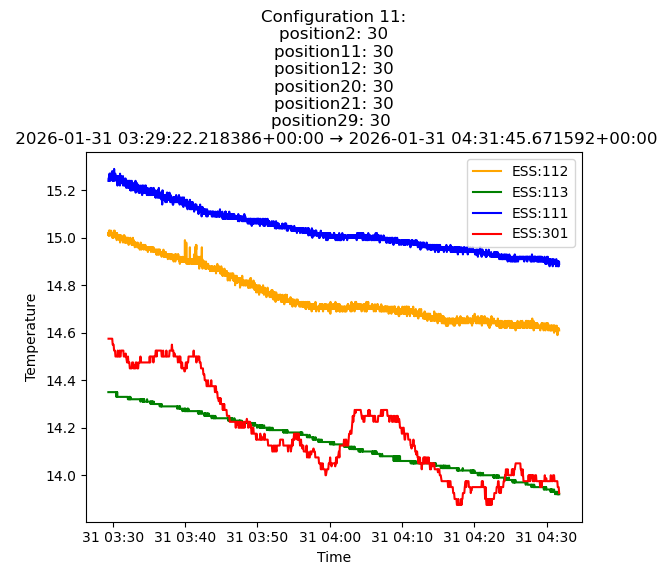

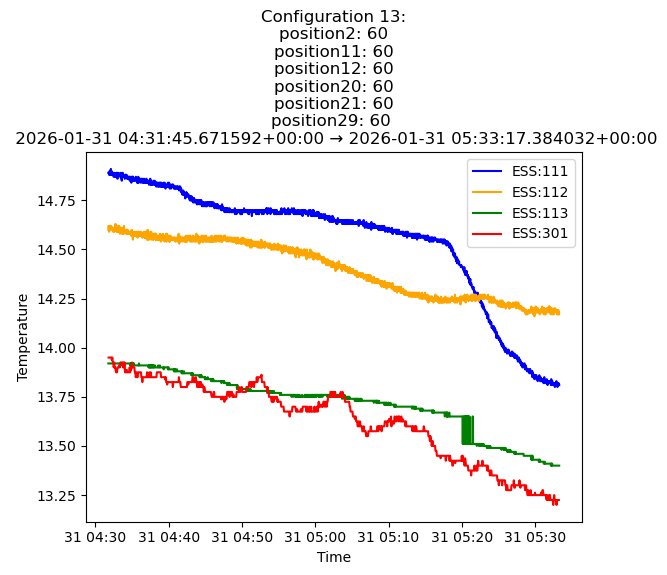

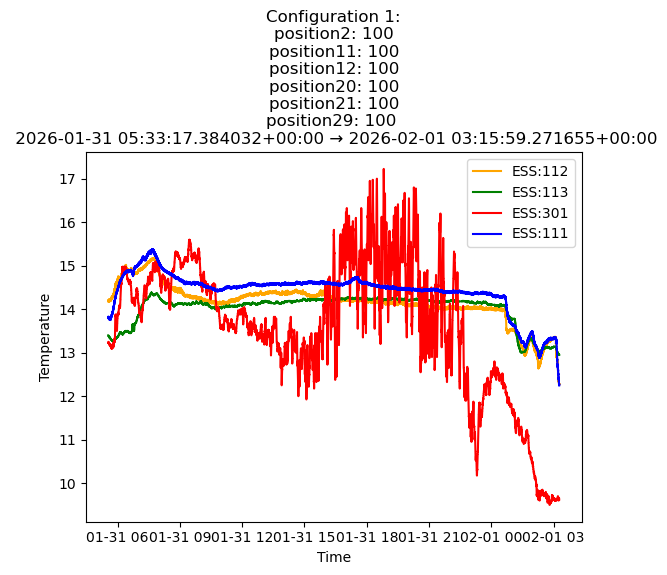

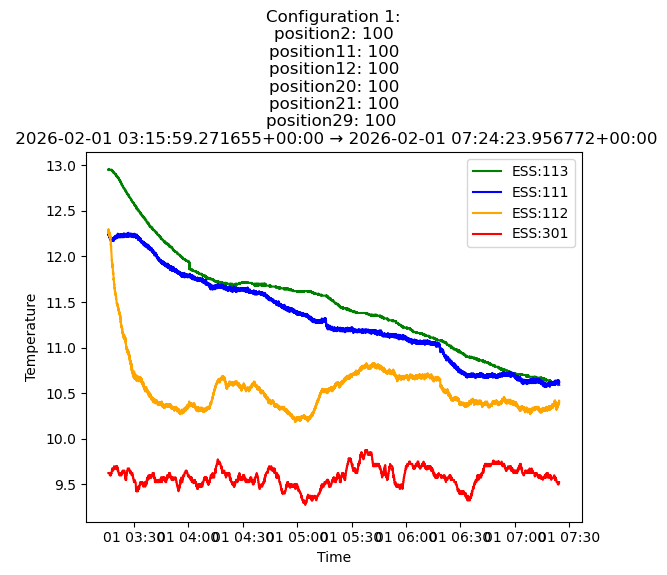

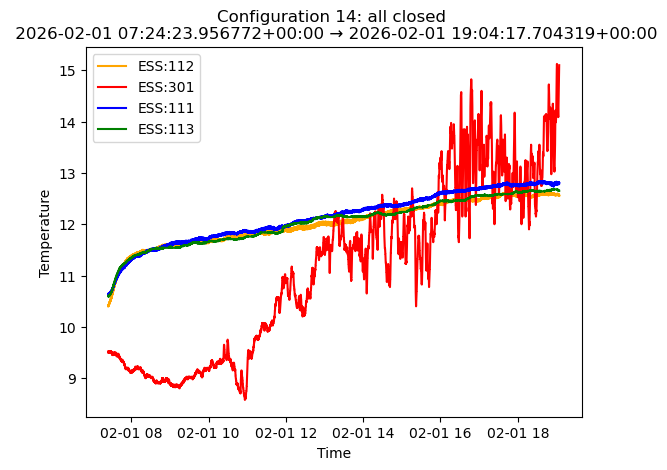

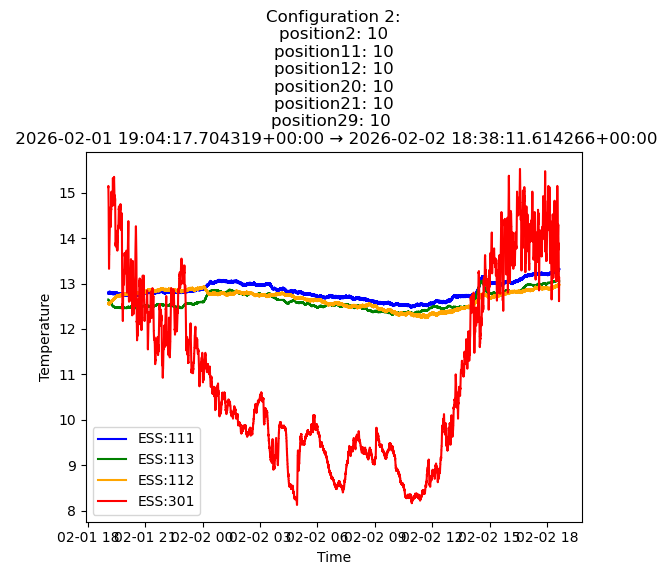

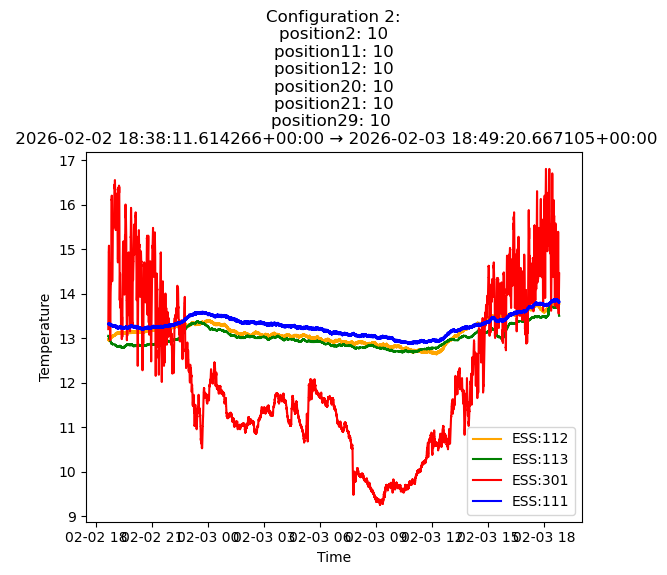

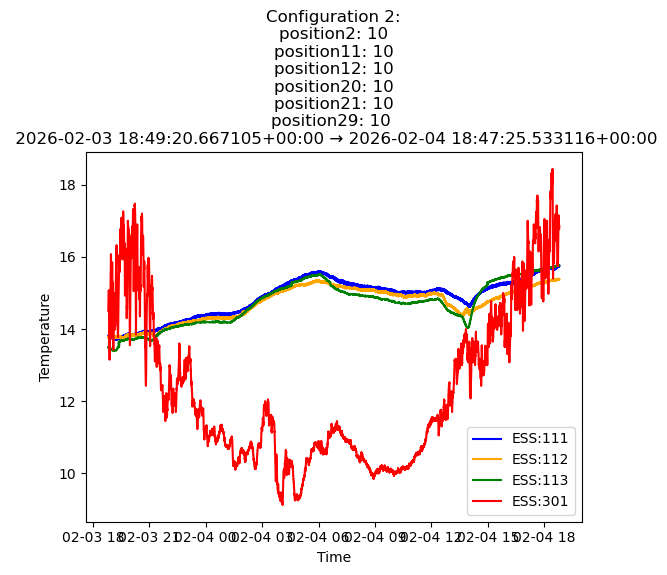

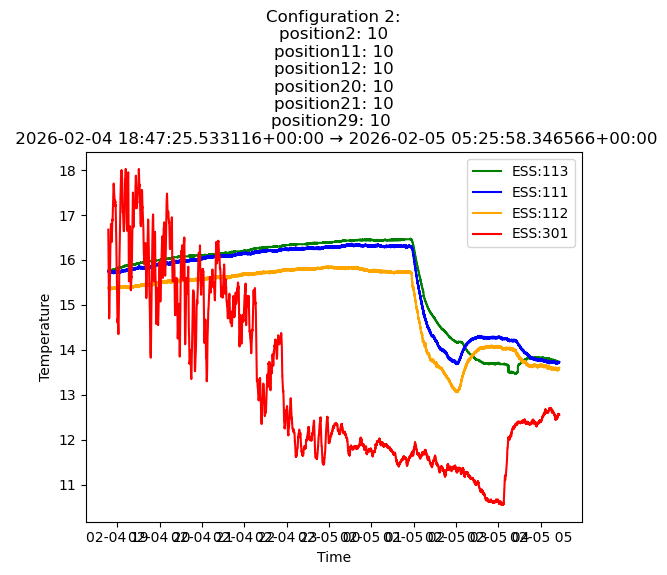

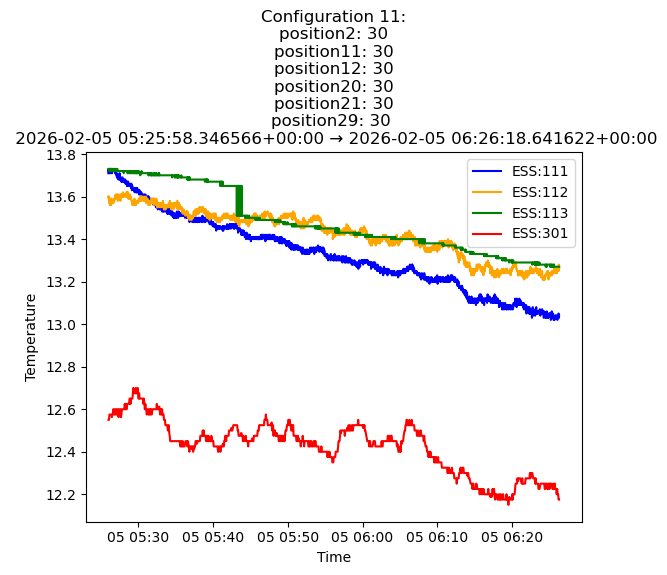

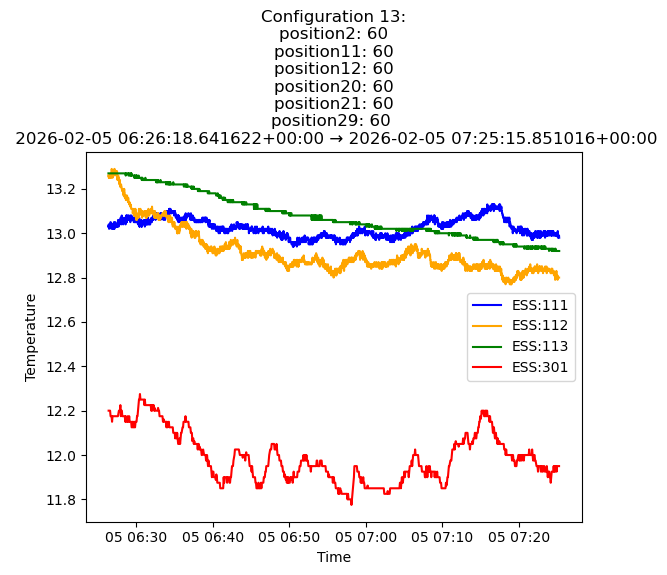

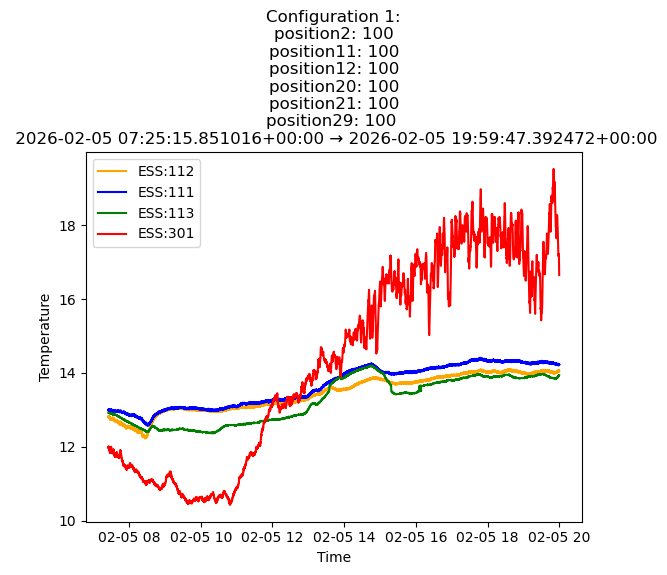

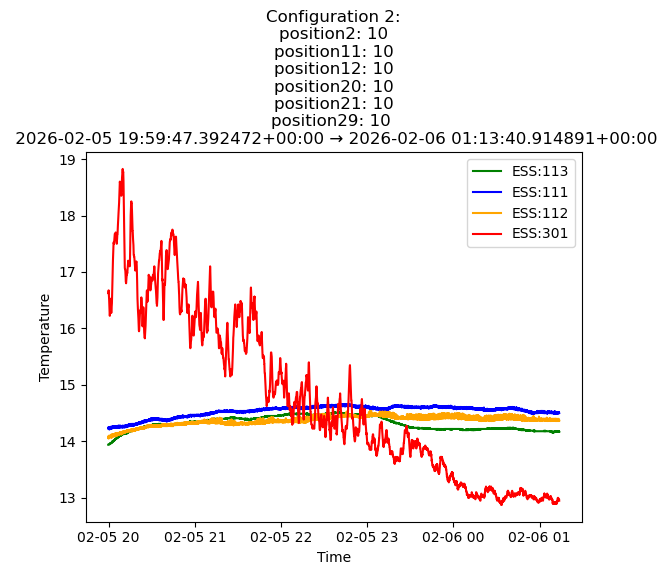

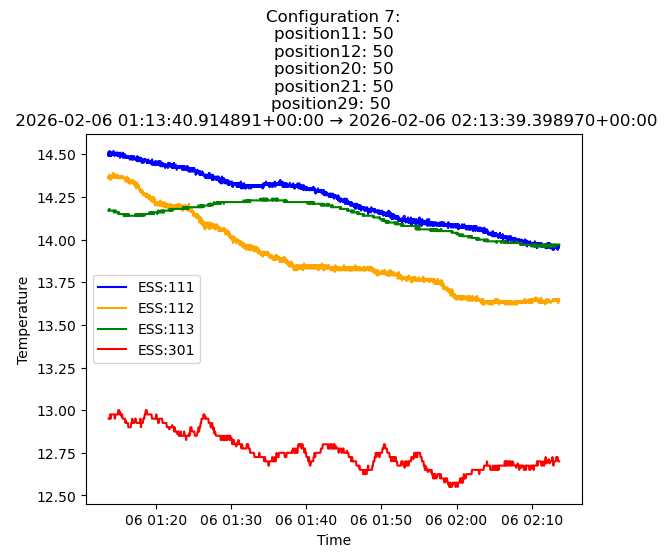

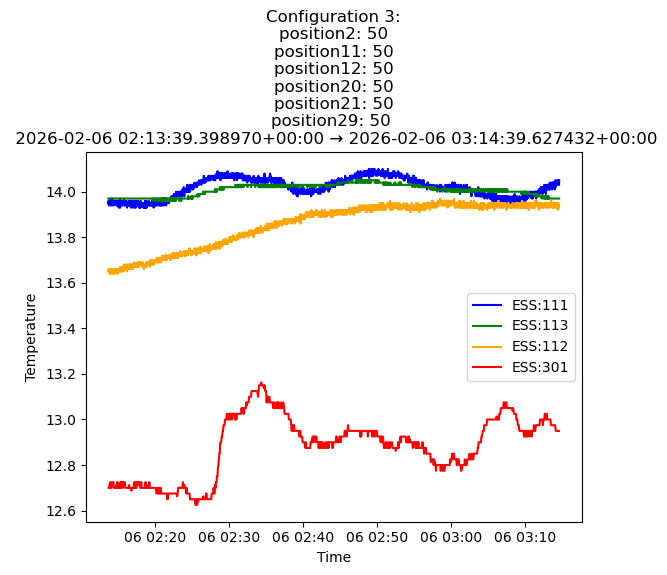

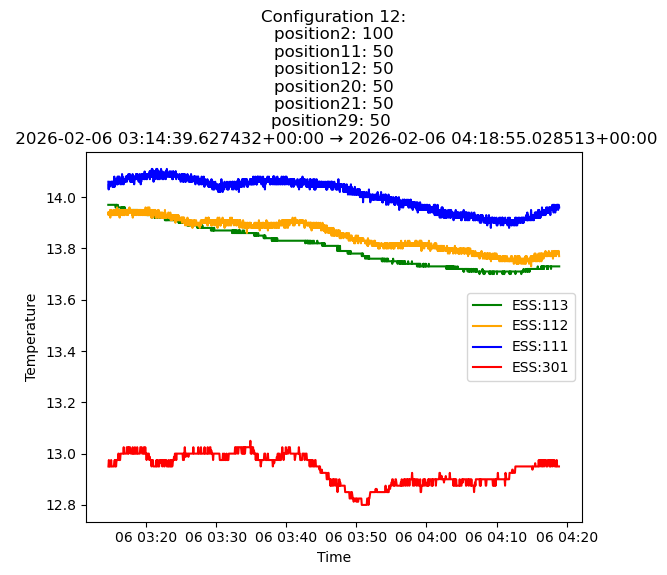

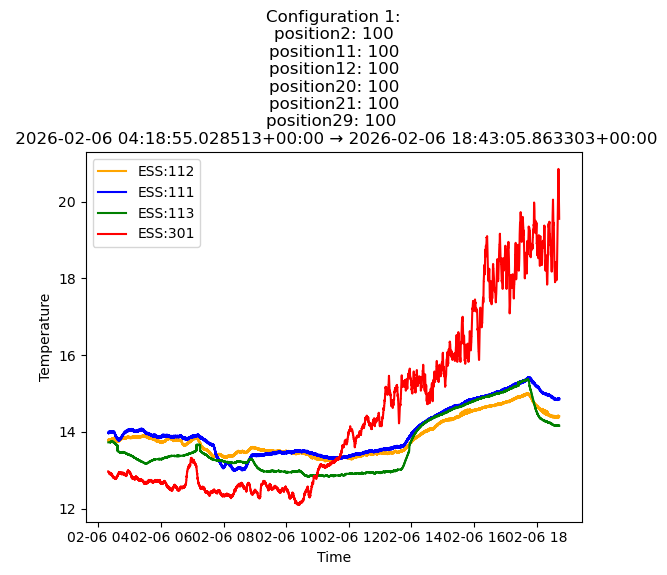

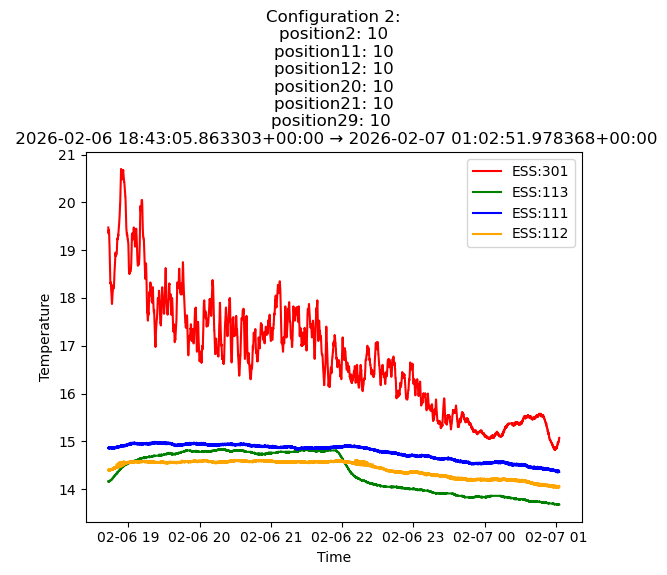

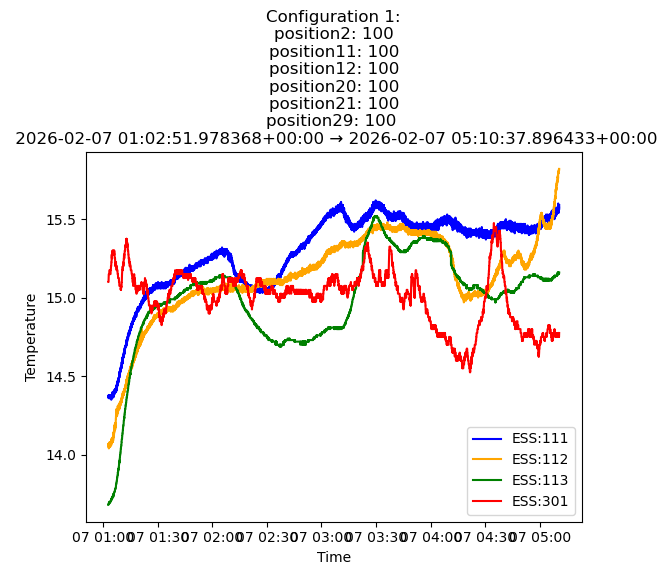

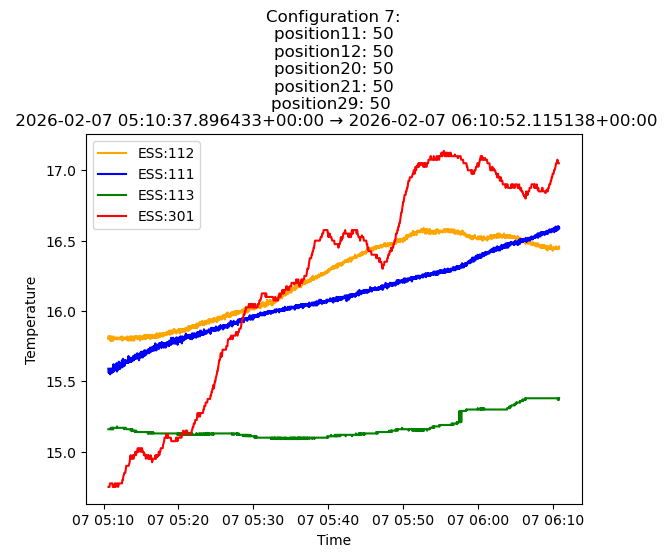

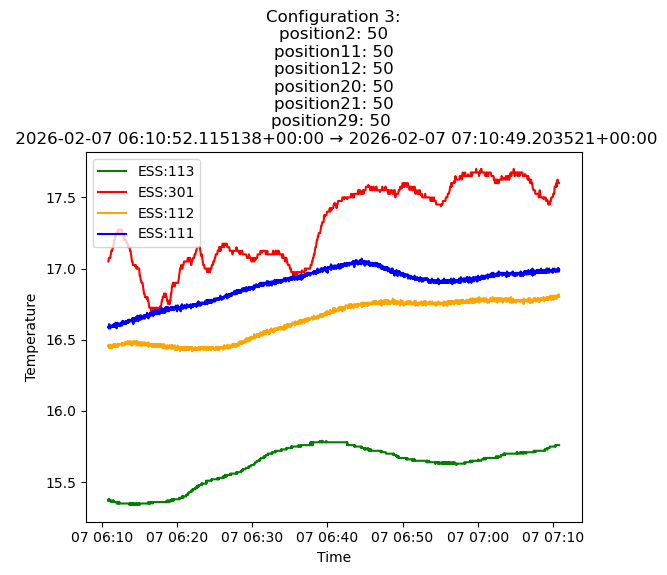

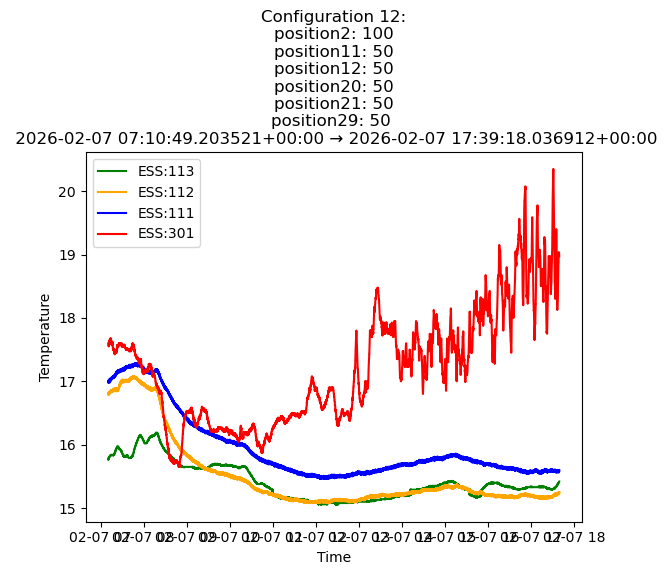

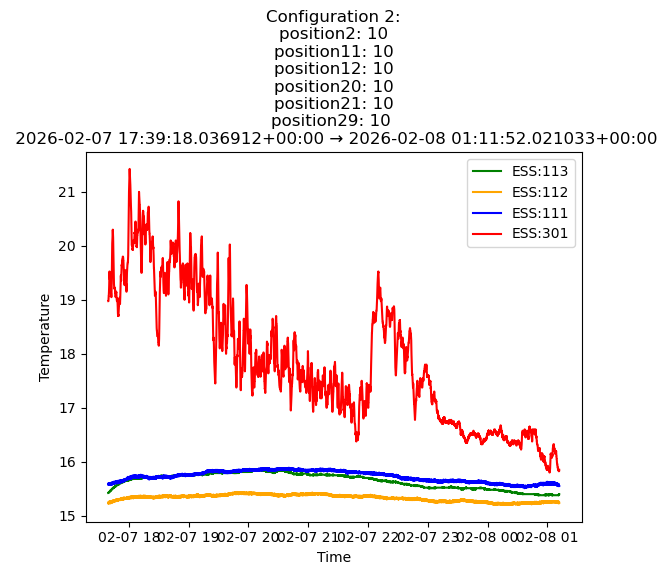

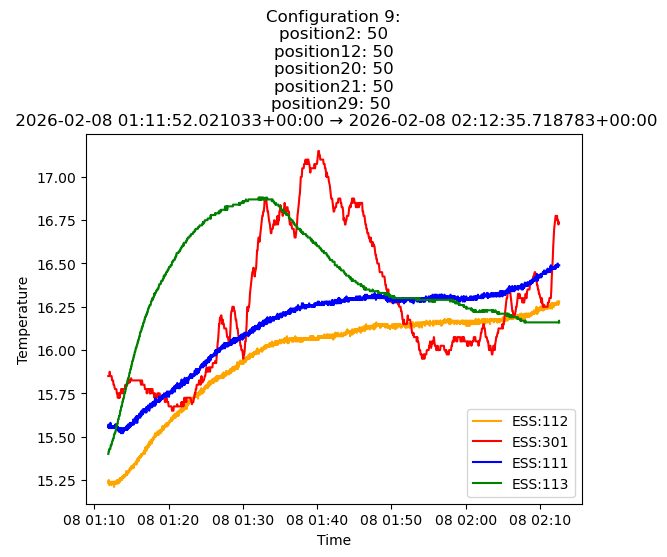

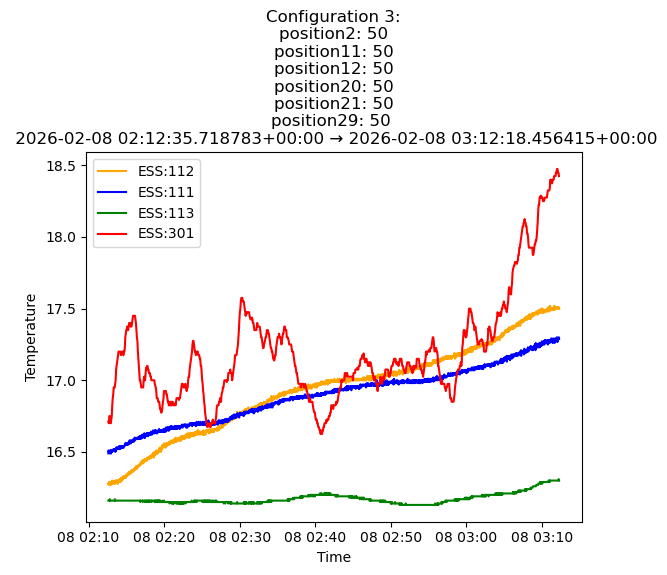

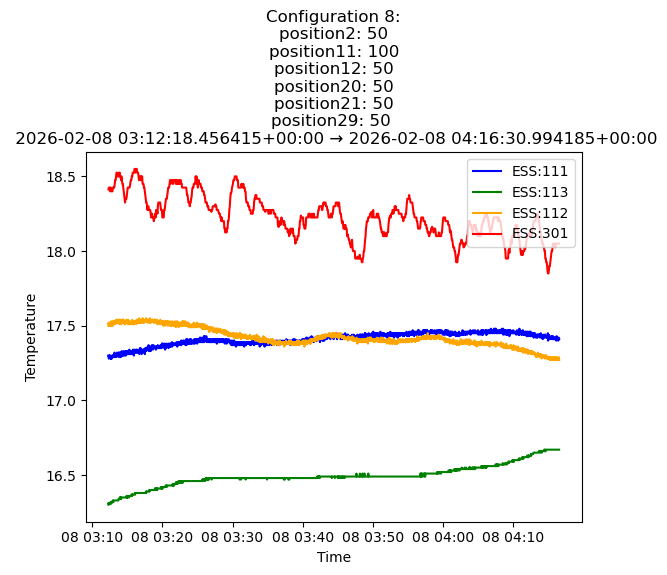

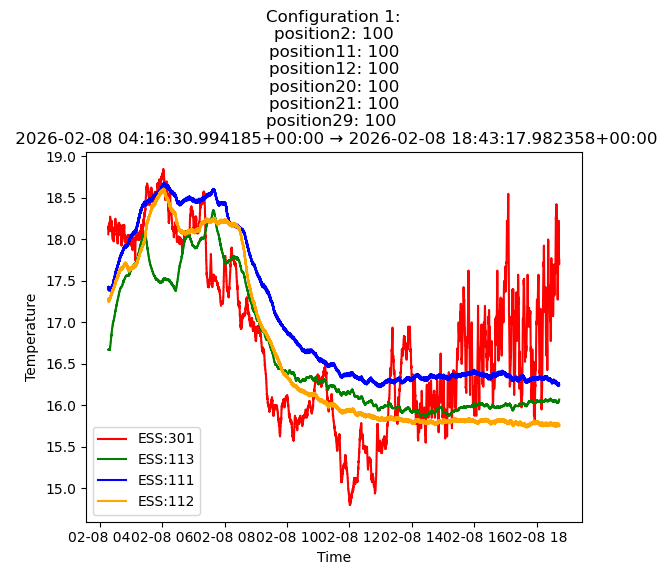

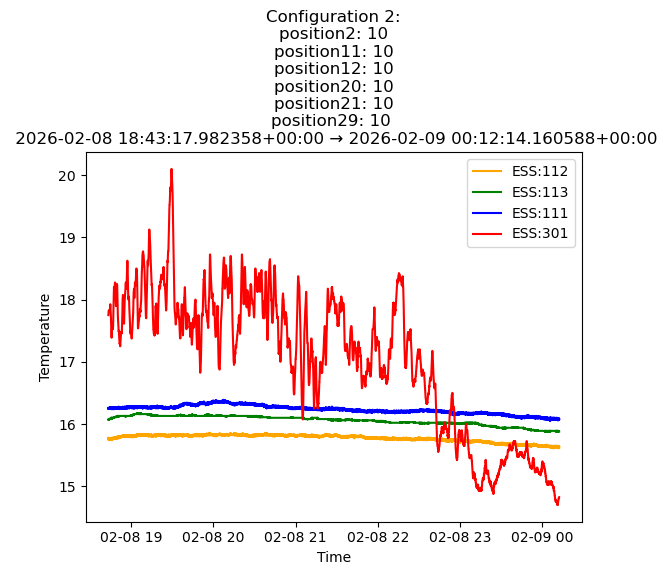

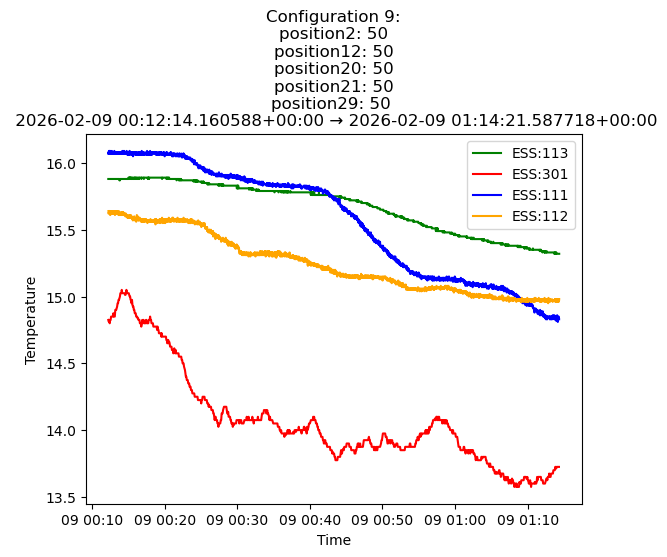

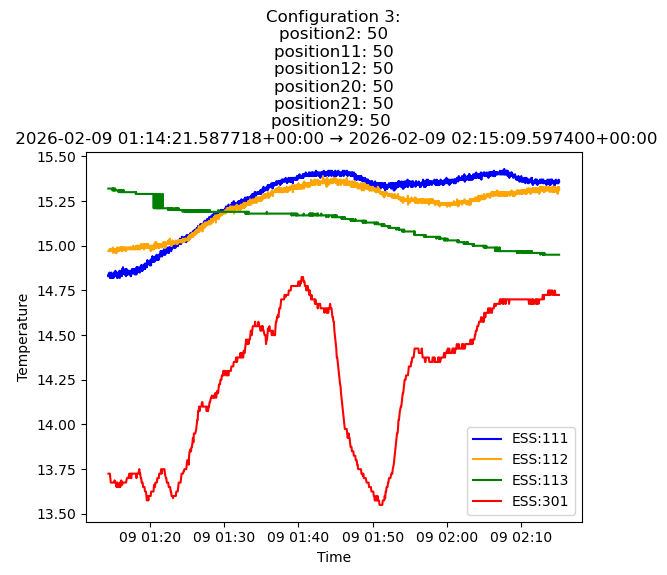

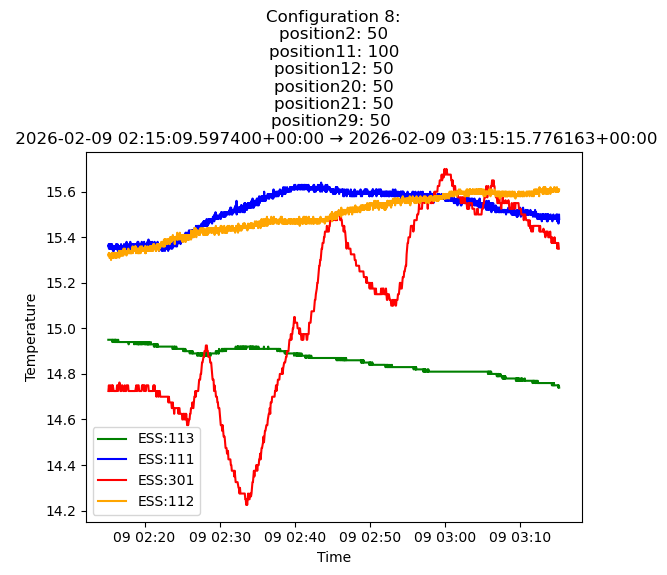

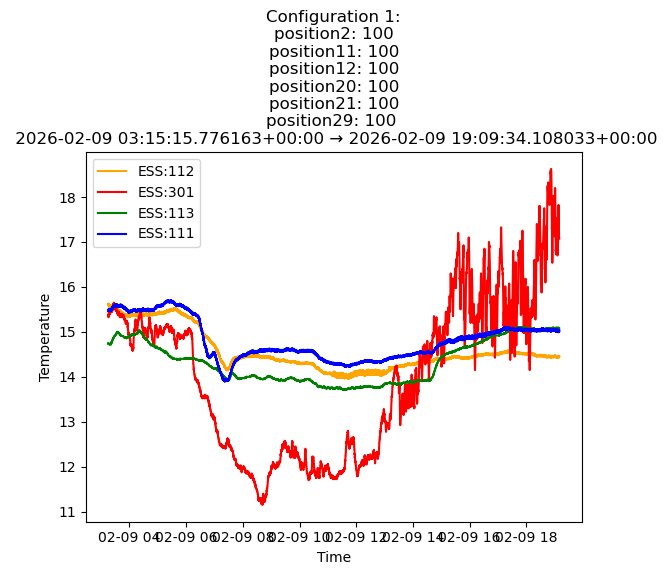

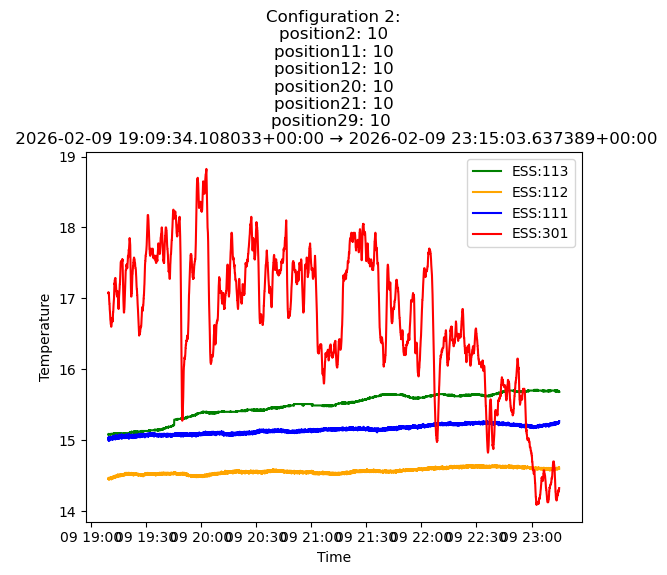

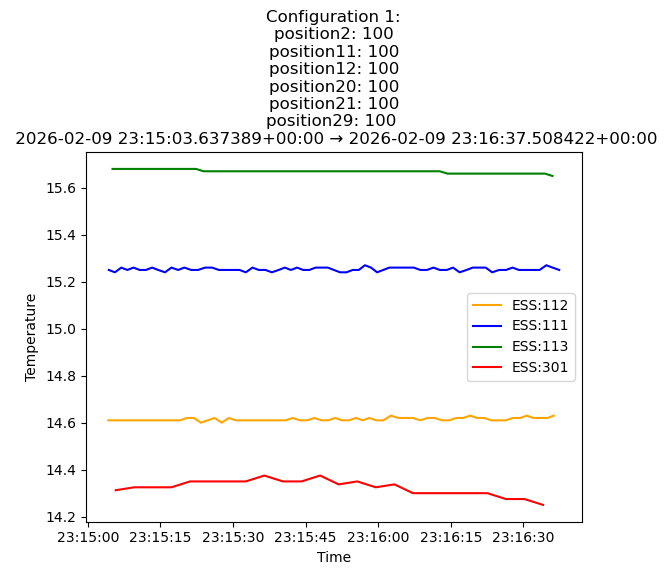

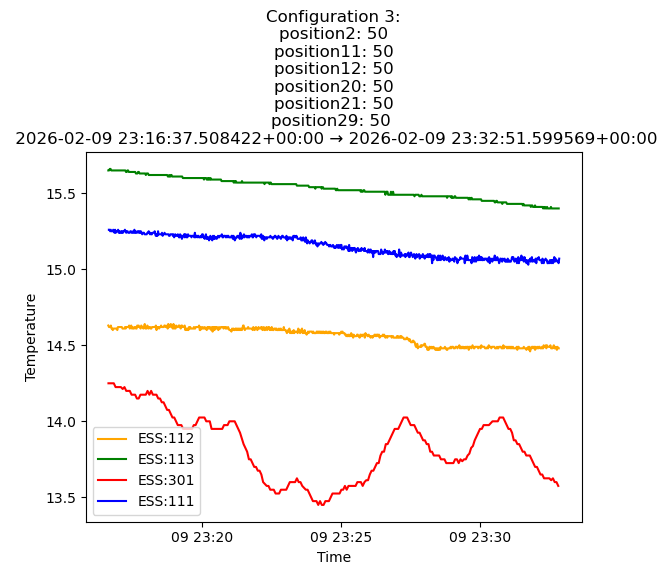

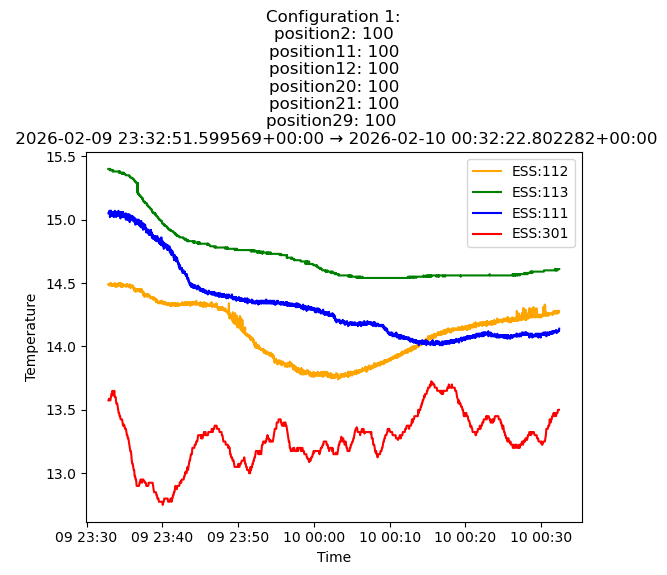

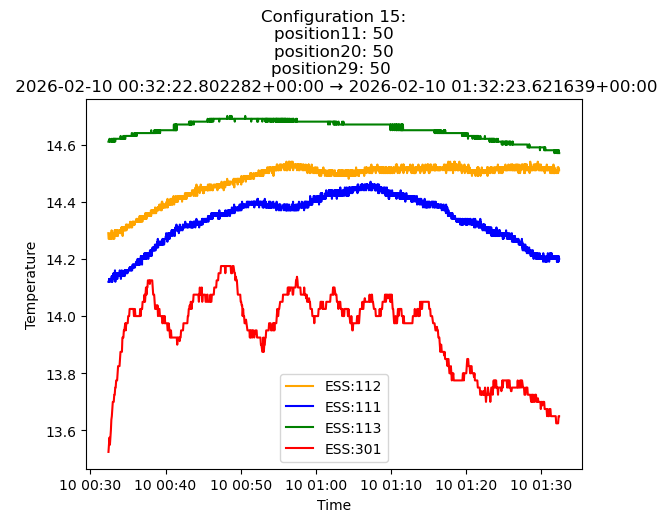

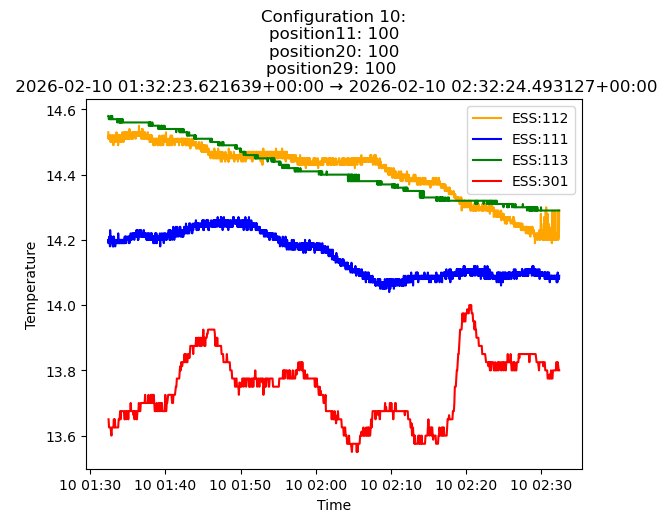

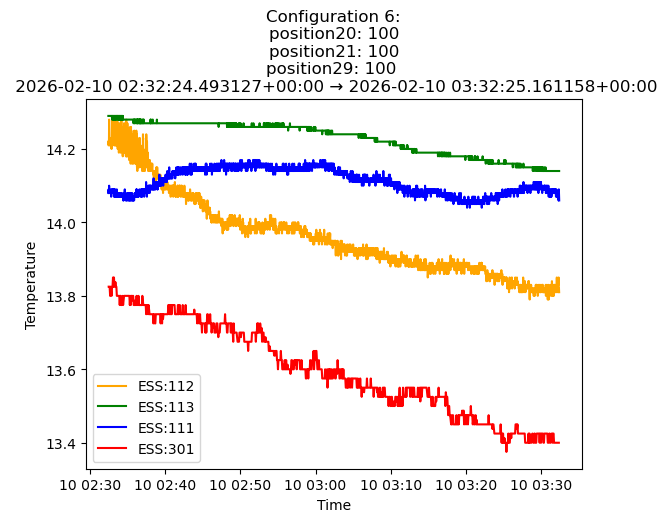

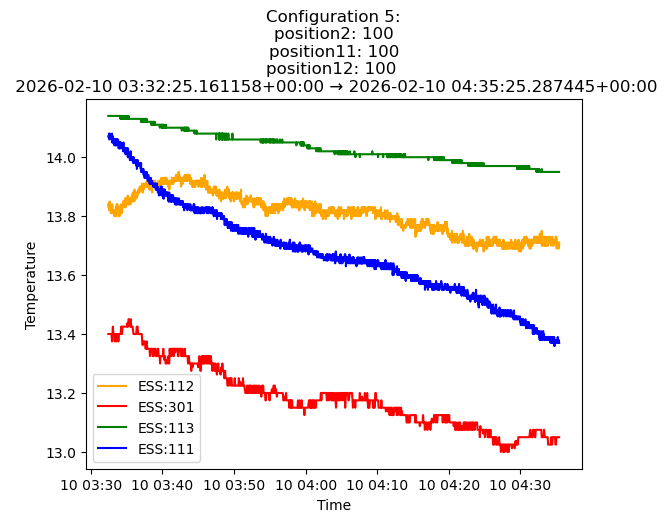

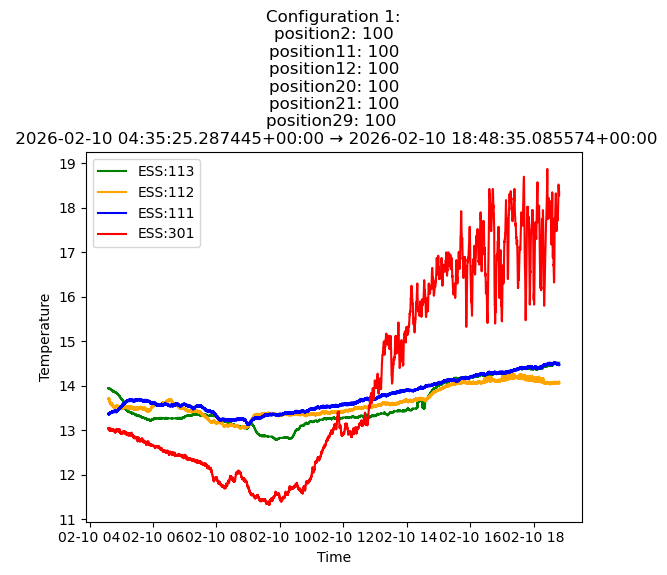

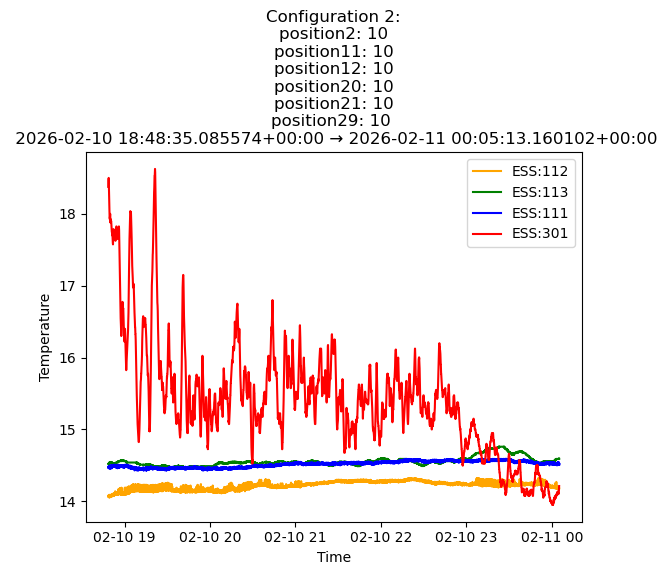

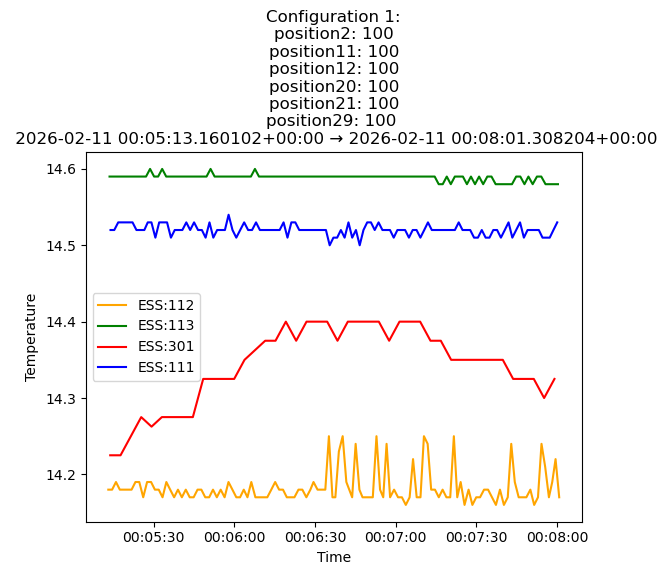

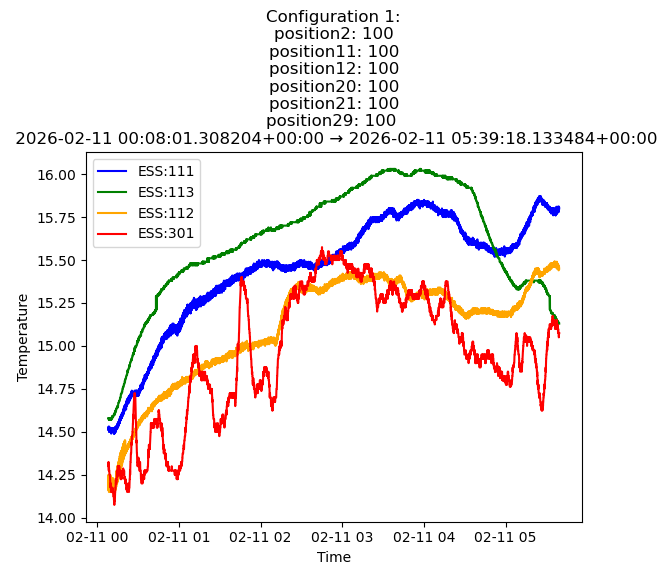

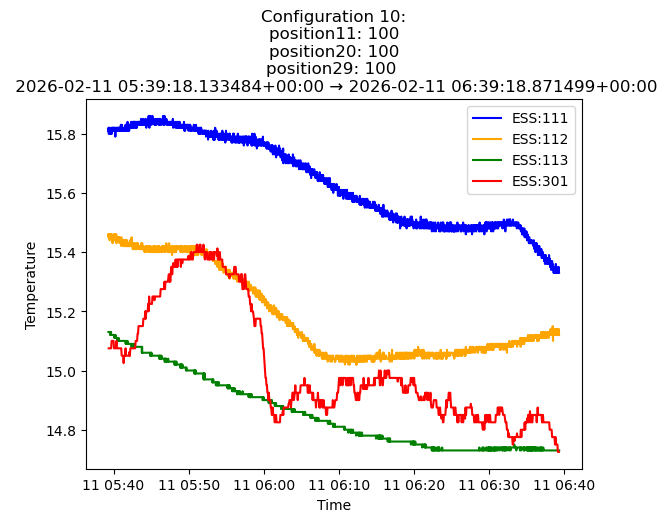

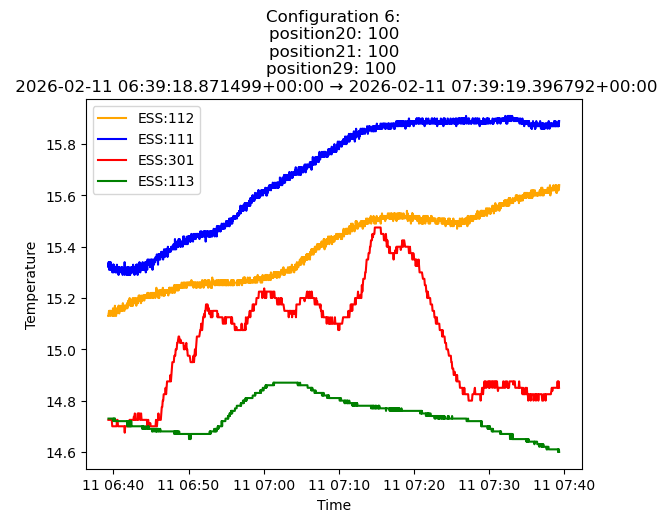

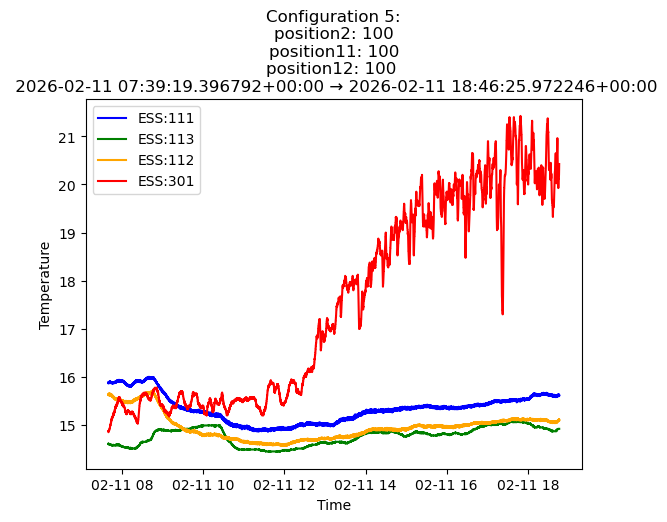

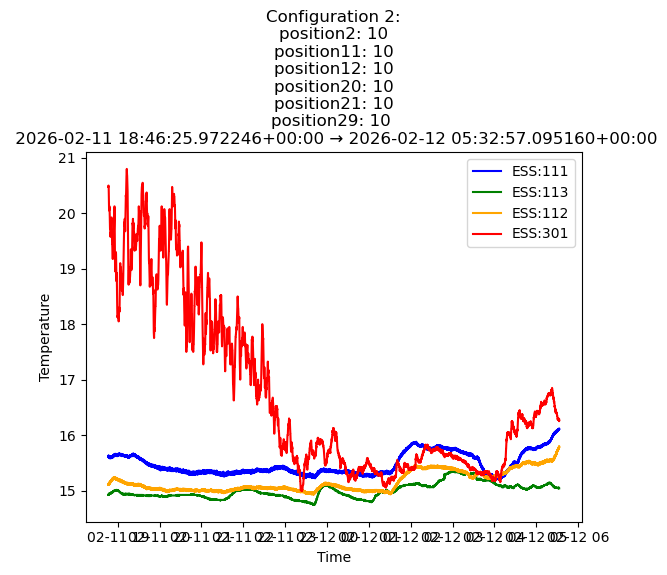

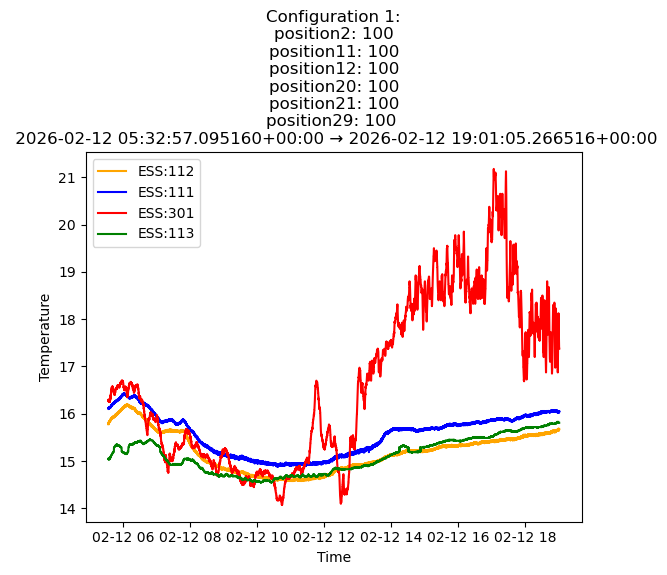

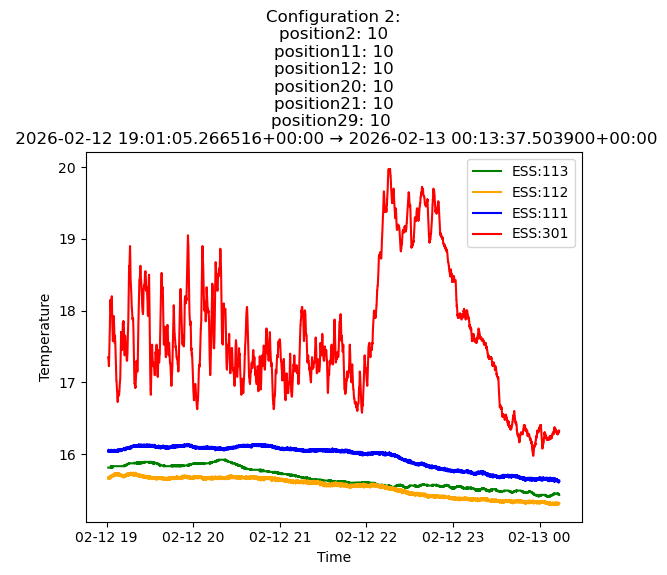

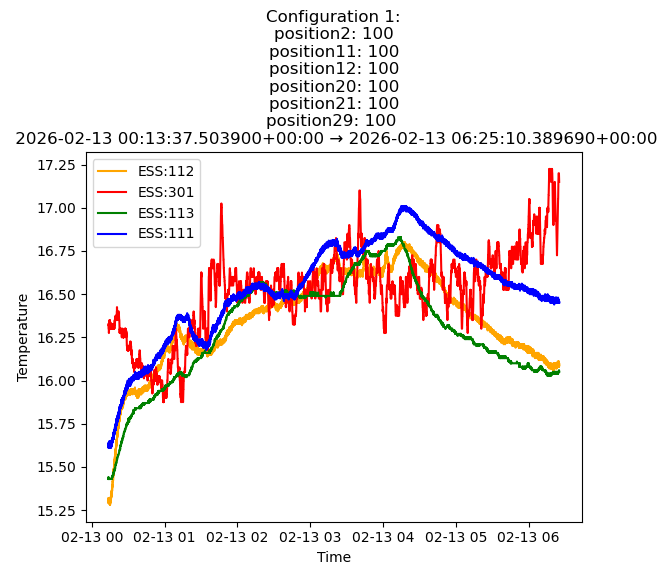

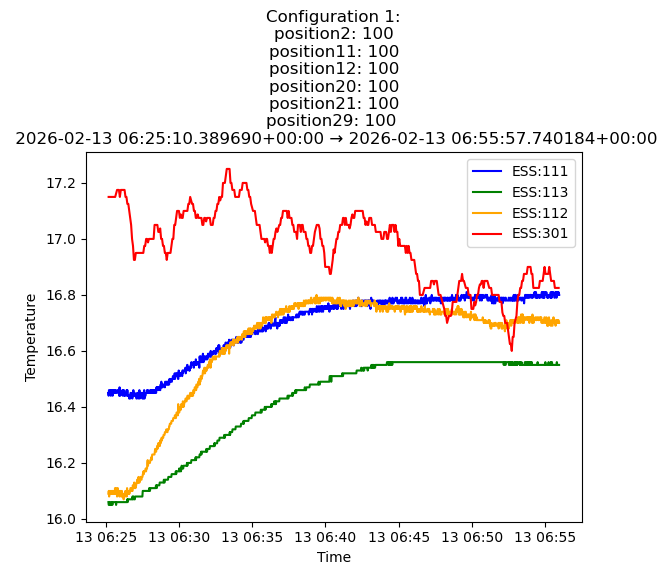

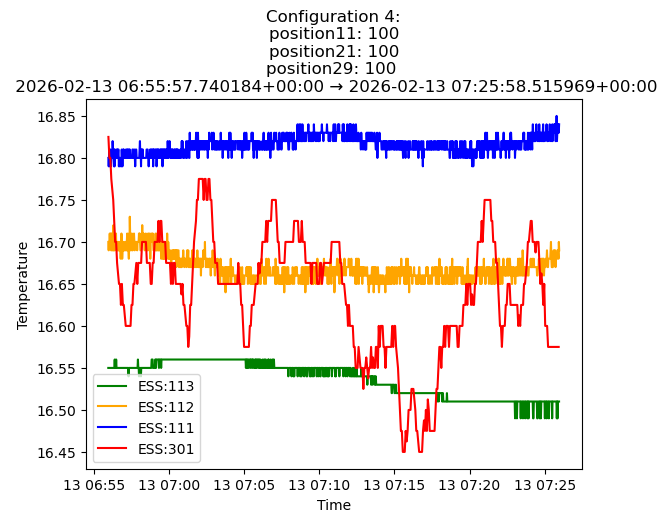

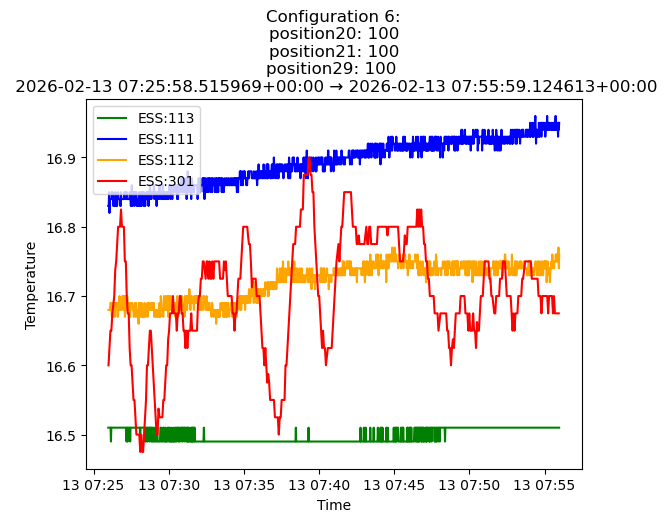

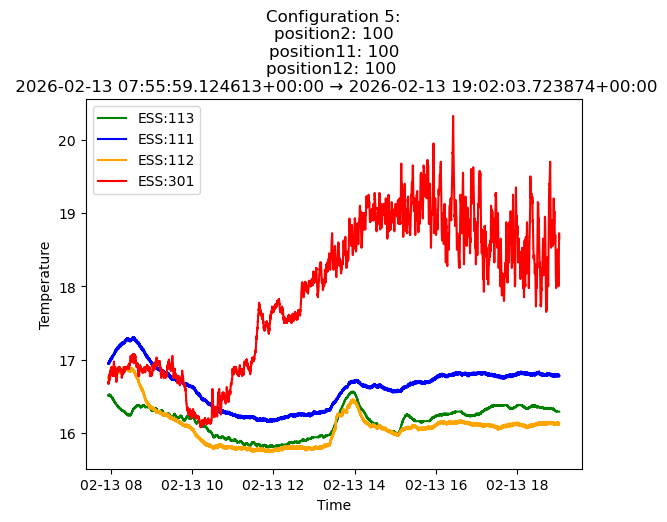

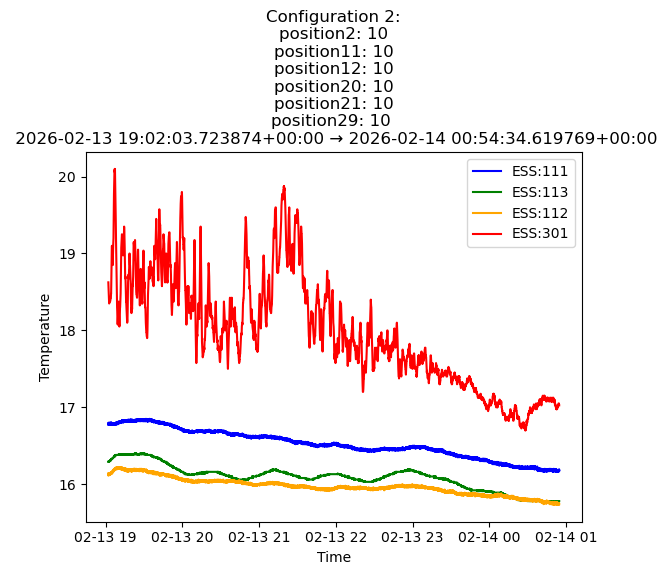

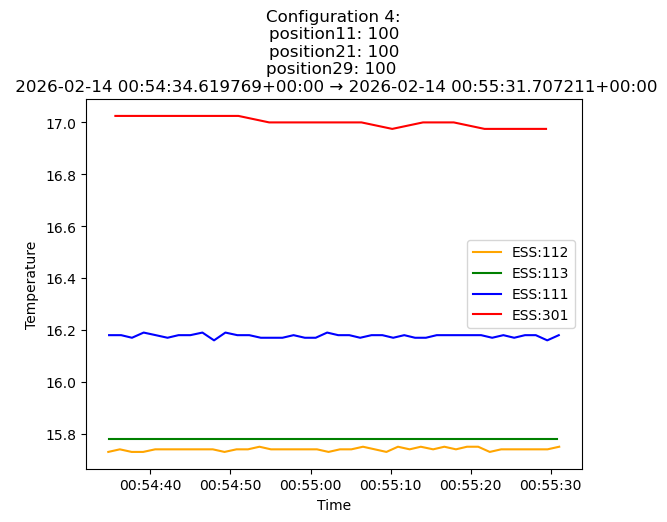

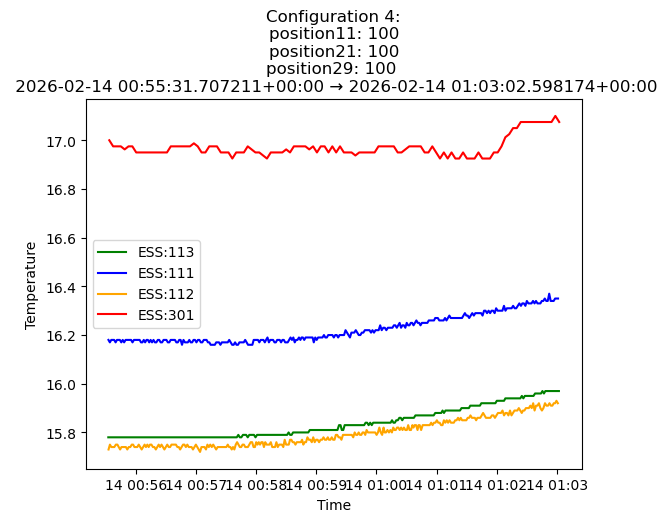

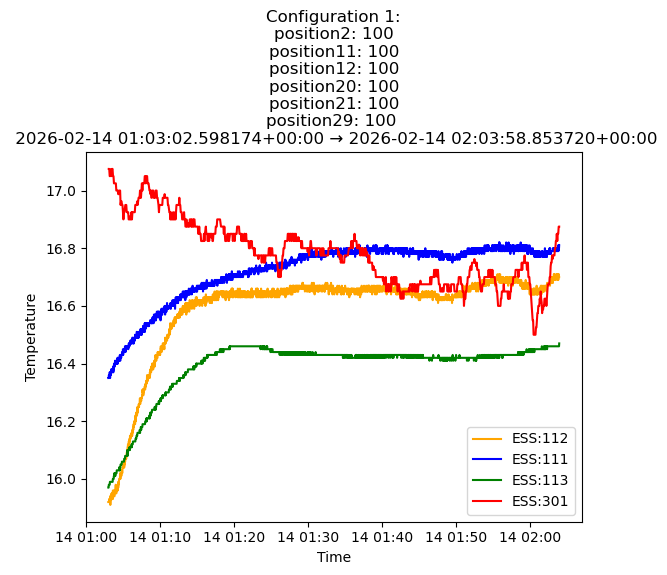

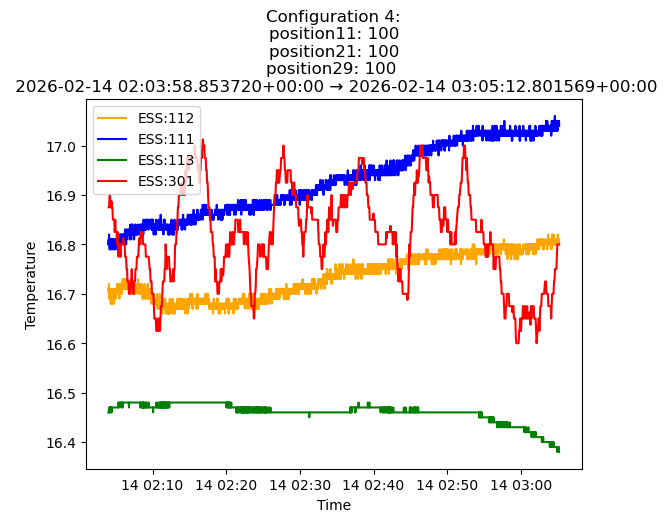

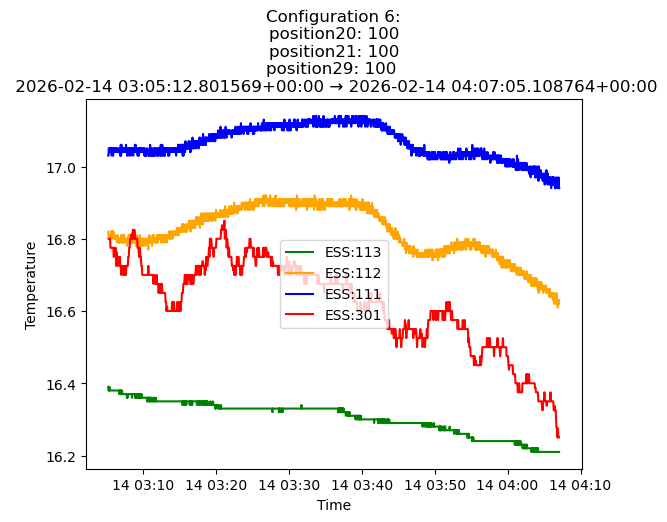

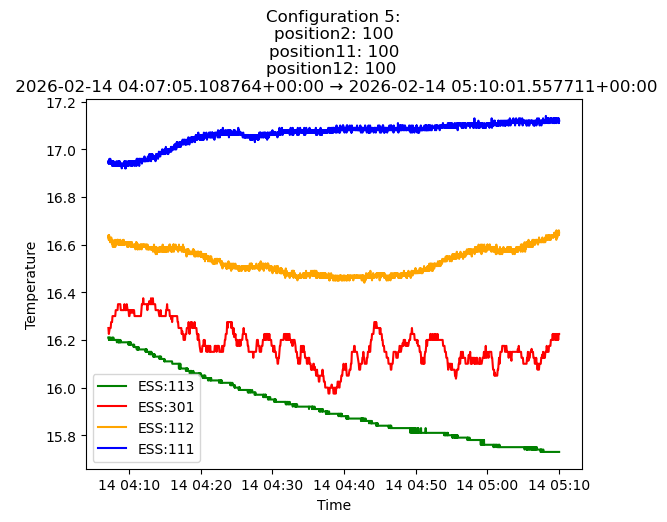

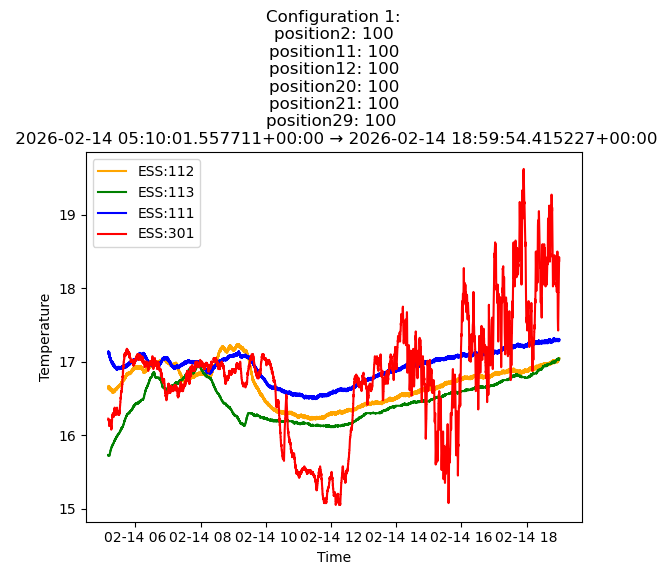

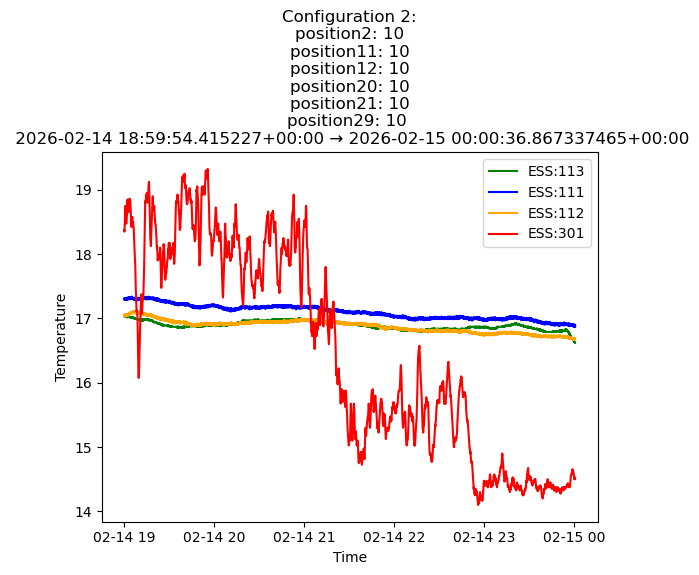

In [17]:
color_map = {
    "ESS:111": "blue",
    "ESS:112": "orange",
    "ESS:113": "green",
    "ESS:301": "red"
}

for _, row in df_setlouvers.iterrows():
    conf = row["conf_label"]
    t0 = row["time_stamp"]
    t1 = row["time_end"]
    
    df_interval = df_temp_merge[
        (df_temp_merge["time"] >= t0) &
        (df_temp_merge["time"] <= t1)
    ]
    
    if df_interval.empty:
        continueshow()
    
    plt.figure()
    
    for sensor in df_interval["private_identity_x"].unique():
        df_s = df_interval[df_interval["private_identity_x"] == sensor]
        plt.plot(
           df_s["time"],
           df_s["temperatureItem0"],
           label=sensor,
           color=color_map.get(sensor, "black")
        )
    
    plt.title(f"{conf} \n {t0} → {t1}")
    plt.xlabel("Time")
    plt.ylabel("Temperature")
    plt.legend()
    plt.show()

# Comparison tables: how much temperatures change for each configuration

### calculate temperature change by interval

In [25]:
df_setlouvers

,position0,position1,position10,position11,position12,position13,position14,position15,position16,position17,...,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,time_stamp,louvers_conf,time_end,conf_label
0,0,0,0,30,30,0,0,0,0,0,...,1.769830e+09,37088,0,0afdb49a,1512418370,1.769830e+09,2026-01-31 03:29:22.218386+00:00,11,2026-01-31 04:31:45.671592+00:00,Configuration 11:\nposition2: 30\nposition11: ...
1,0,0,0,60,60,0,0,0,0,0,...,1.769834e+09,37176,0,0afdb49a,1512418370,1.769834e+09,2026-01-31 04:31:45.671592+00:00,13,2026-01-31 05:33:17.384032+00:00,Configuration 13:\nposition2: 60\nposition11: ...
2,0,0,0,100,100,0,0,0,0,0,...,1.769838e+09,37261,0,0afdb49a,1512418370,1.769838e+09,2026-01-31 05:33:17.384032+00:00,1,2026-02-01 03:15:59.271655+00:00,Configuration 1:\nposition2: 100\nposition11: ...
3,0,0,0,100,100,0,0,0,0,0,...,1.769916e+09,60487,0,0afdb49a,1512418370,1.769916e+09,2026-02-01 03:15:59.271655+00:00,1,2026-02-01 07:24:23.956772+00:00,Configuration 1:\nposition2: 100\nposition11: ...
4,0,0,0,0,0,0,0,0,0,0,...,1.769931e+09,65874,0,0afdb49a,1512418370,1.769931e+09,2026-02-01 07:24:23.956772+00:00,14,2026-02-01 19:04:17.704319+00:00,Configuration 14: all closed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0,0,0,100,0,0,0,0,0,0,...,1.771035e+09,277346,0,0afdb49a,1512418370,1.771035e+09,2026-02-14 02:03:58.853720+00:00,4,2026-02-14 03:05:12.801569+00:00,Configuration 4:\nposition11: 100\nposition21:...
60,0,0,0,0,0,0,0,0,0,0,...,1.771038e+09,277961,0,0afdb49a,1512418370,1.771038e+09,2026-02-14 03:05:12.801569+00:00,6,2026-02-14 04:07:05.108764+00:00,Configuration 6:\nposition20: 100\nposition21:...
61,0,0,0,100,100,0,0,0,0,0,...,1.771042e+09,278489,0,0afdb49a,1512418370,1.771042e+09,2026-02-14 04:07:05.108764+00:00,5,2026-02-14 05:10:01.557711+00:00,Configuration 5:\nposition2: 100\nposition11: ...
62,0,0,0,100,100,0,0,0,0,0,...,1.771046e+09,279125,0,0afdb49a,1512418370,1.771046e+09,2026-02-14 05:10:01.557711+00:00,1,2026-02-14 18:59:54.415227+00:00,Configuration 1:\nposition2: 100\nposition11: ...


In [27]:
results = []

for _, row in df_setlouvers.iterrows():
    conf_num = row["louvers_conf"]
    conf = row["conf_label"]
    t0 = row["time_stamp"]
    t1 = row["time_end"]
    
    df_interval = df_temp_merge[
        (df_temp_merge["time"] >= t0) &
        (df_temp_merge["time"] <= t1)
    ]
    
    if df_interval.empty:
        continue
    
    for sensor in df_interval["private_identity_x"].unique():
        df_s = df_interval[df_interval["private_identity_x"] == sensor]
        
        temp_change = df_s["temperatureItem0"].max() - df_s["temperatureItem0"].min()
        
        results.append({
            "louvers_conf": conf_num,
            "conf_label": conf,
            "sensor": sensor,
            "delta_T": temp_change,
            "duration_min": (t1 - t0).total_seconds() / 60
        })

In [29]:
df_changes = pd.DataFrame(results)

In [30]:
df_changes.head()

,louvers_conf,conf_label,sensor,delta_T,duration_min
0,11,Configuration 11:\nposition2: 30\nposition11: ...,ESS:112,0.44,62.390887
1,11,Configuration 11:\nposition2: 30\nposition11: ...,ESS:113,0.43,62.390887
2,11,Configuration 11:\nposition2: 30\nposition11: ...,ESS:111,0.41,62.390887
3,11,Configuration 11:\nposition2: 30\nposition11: ...,ESS:301,0.70,62.390887
4,13,Configuration 13:\nposition2: 60\nposition11: ...,ESS:111,1.11,61.528541


In [33]:
df_summary = (
    df_changes
    .groupby(["louvers_conf","conf_label", "sensor"])
    .agg(
        mean_delta_T=("delta_T", "mean"),
        median_delta_T=("delta_T", "median"),
        std_delta_T=("delta_T", "std"),
        n_intervals=("delta_T", "count")
    )
    .reset_index()
)

In [34]:
df_summary

,louvers_conf,conf_label,sensor,mean_delta_T,median_delta_T,std_delta_T,n_intervals
0,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:111,1.362353,1.400001,0.855684,17
1,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:112,1.420588,1.520000,0.813699,17
2,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:113,1.351177,1.400000,0.771483,17
3,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:301,3.719118,1.500000,3.460610,17
4,2,Configuration 2:\nposition2: 10\nposition11: 1...,ESS:111,0.818571,0.589999,0.710080,14
5,2,Configuration 2:\nposition2: 10\nposition11: 1...,ESS:112,0.762143,0.490000,0.711588,14
6,2,Configuration 2:\nposition2: 10\nposition11: 1...,ESS:113,0.910000,0.620000,0.798209,14
7,2,Configuration 2:\nposition2: 10\nposition11: 1...,ESS:301,5.887500,5.712499,1.583630,14
8,3,Configuration 3:\nposition2: 50\nposition11: 5...,ESS:111,0.462000,0.490000,0.265932,5
9,3,Configuration 3:\nposition2: 50\nposition11: 5...,ESS:112,0.518000,0.400000,0.420440,5
